# Previsão de Atraso em Ordens de Produção

**PCP** | Machine Learning com scikit-learn

Trabalhando com PCP a gente vive apagando incêndio: o atraso só aparece quando a ordem já devia estar pronta.
A ideia deste projeto é inverter isso — usar o **histórico de ordens de produção** para treinar um modelo que lê as
informações de uma ordem nova e estima se ela tende a sair **Adiantada**, **No_Prazo** ou **Atrasada**.

Com essa previsão em mãos dá tempo de agir: repriorizar a fila, negociar prazo, realocar operador ou garantir material antes do problema virar bola de neve.

In [1]:
import pandas as pd

tabela = pd.read_csv("ordens_producao.csv")

print(f"{tabela.shape[0]} ordens no histórico, {tabela.shape[1]} colunas")
tabela.head()

6000 ordens no histórico, 15 colunas


,id_ordem,mes,produto,maquina,turno,quantidade_pecas,tempo_setup_min,horas_maquina_previstas,prioridade,materia_prima_ok,operadores_alocados,taxa_refugo_pct,paradas_manutencao_mes,dias_ate_prazo,status_prazo
0,OP-00001,2,Suporte,Torno-03,Noite,1196,38.0,48.93,Média,Sim,1,5.65,3,5,Atrasado
1,OP-00002,10,Carcaça,Torno-03,Manhã,1770,147.0,55.83,Média,Sim,1,6.17,4,12,Atrasado
2,OP-00003,8,Suporte,CNC-01,Tarde,4311,178.0,75.46,Urgente,Sim,1,2.83,3,20,No_Prazo
3,OP-00004,6,Flange,CNC-01,Manhã,558,74.0,9.48,Baixa,Sim,3,1.71,4,22,No_Prazo
4,OP-00005,6,Flange,Torno-03,Manhã,587,158.0,12.94,Baixa,Sim,1,2.15,3,45,Adiantado


## 1. Como está o desempenho hoje

Antes de qualquer modelo, vale entender o histórico: qual a proporção de atrasos e quais variáveis parecem separar
uma ordem que cumpre prazo de uma que não cumpre.

In [2]:
# distribuição do status no histórico (%)
(tabela["status_prazo"].value_counts(normalize=True) * 100).round(1)

status_prazo
No_Prazo     38.0
Atrasado     32.0
Adiantado    30.0
Name: proportion, dtype: float64

In [3]:
# média das variáveis por status — já dá pra ver o que puxa o atraso
tabela.groupby("status_prazo")[["quantidade_pecas", "dias_ate_prazo",
                                "operadores_alocados", "taxa_refugo_pct"]].mean().round(1)

,quantidade_pecas,dias_ate_prazo,operadores_alocados,taxa_refugo_pct
status_prazo,,,,
Adiantado,1702.5,31.9,4.0,3.7
Atrasado,3175.6,18.5,3.1,4.6
No_Prazo,2656.2,22.5,3.4,4.3


## 2. Preparando os dados

O modelo só entende número, então preciso converter as colunas de texto (`produto`, `maquina`, `turno`,
`prioridade`, `materia_prima_ok`). Uso o `LabelEncoder` e **guardo cada codificador** — as ordens novas vão
precisar passar pela mesma conversão depois.

O `id_ordem` é só identificação, não ajuda a prever nada, então sai da análise.

In [4]:
from sklearn.preprocessing import LabelEncoder

colunas_texto = ["produto", "maquina", "turno", "prioridade", "materia_prima_ok"]

codificadores = {}
for coluna in colunas_texto:
    cod = LabelEncoder()
    tabela[coluna] = cod.fit_transform(tabela[coluna])
    codificadores[coluna] = cod  # guardado para codificar as ordens novas com o mesmo padrão

tabela.head(3)

,id_ordem,mes,produto,maquina,turno,quantidade_pecas,tempo_setup_min,horas_maquina_previstas,prioridade,materia_prima_ok,operadores_alocados,taxa_refugo_pct,paradas_manutencao_mes,dias_ate_prazo,status_prazo
0,OP-00001,2,4,4,1,1196,38.0,48.93,2,1,1,5.65,3,5,Atrasado
1,OP-00002,10,0,4,0,1770,147.0,55.83,2,1,1,6.17,4,12,Atrasado
2,OP-00003,8,4,0,2,4311,178.0,75.46,3,1,1,2.83,3,20,No_Prazo


## 3. Separando variáveis de entrada e resposta

- `y` = o que quero prever → `status_prazo`
- `x` = o que uso para prever → todas as outras colunas (menos o id)

Reservo 25% dos dados para teste, para avaliar o modelo com ordens que ele nunca viu.

In [5]:
from sklearn.model_selection import train_test_split

y = tabela["status_prazo"]
x = tabela.drop(columns=["status_prazo", "id_ordem"])

x_treino, x_teste, y_treino, y_teste = train_test_split(
    x, y, test_size=0.25, random_state=42)

print(f"{len(x_treino)} ordens para treino | {len(x_teste)} para teste")

4500 ordens para treino | 1500 para teste


## 4. Treinando os modelos

Vou comparar dois algoritmos de classificação:

| Modelo | Ideia |
|---|---|
| **Random Forest** | várias árvores de decisão votando juntas |
| **KNN** | classifica a ordem pelos "vizinhos" mais parecidos do histórico |

Dois detalhes que melhoraram o resultado:
- o Random Forest ganhou **400 árvores** em vez das 100 padrão — mais votos, decisão mais estável;
- o KNN trabalha com **distância**, então as variáveis precisam estar na mesma escala (`StandardScaler`),
  senão `quantidade_pecas` (milhares) esmaga variáveis de 0 a 8 como `taxa_refugo_pct`.

Quem tiver a melhor acurácia nos dados de teste leva o job de prever as ordens novas.

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

modelo_arvore = RandomForestClassifier(n_estimators=400, random_state=42, n_jobs=-1)

# pipeline: escala os dados e só depois aplica o KNN
modelo_knn = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=7))

modelo_arvore.fit(x_treino, y_treino)
modelo_knn.fit(x_treino, y_treino)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('standardscaler', ...), ('kneighborsclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](3,)","['Adiantado','Atrasado','No_Prazo']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['mes','produto','maquina',...,'taxa_refugo_pct','paradas_manutencao_mes', 'dias_ate_prazo']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [7]:
from sklearn.metrics import accuracy_score

prev_arvore = modelo_arvore.predict(x_teste)
prev_knn = modelo_knn.predict(x_teste)

print(f"Random Forest: {accuracy_score(y_teste, prev_arvore):.1%}")
print(f"KNN:           {accuracy_score(y_teste, prev_knn):.1%}")

Random Forest: 80.5%
KNN:           74.3%


In [8]:
# relatório detalhado do melhor modelo, classe por classe
from sklearn.metrics import classification_report

print(classification_report(y_teste, prev_arvore))

              precision    recall  f1-score   support

   Adiantado       0.84      0.75      0.79       457
    Atrasado       0.93      0.83      0.88       500
    No_Prazo       0.69      0.82      0.75       543

    accuracy                           0.80      1500
   macro avg       0.82      0.80      0.81      1500
weighted avg       0.82      0.80      0.81      1500



## 5. O que mais pesa para uma ordem atrasar

Acertar a previsão é bom, mas entender o **porquê** é o que muda a rotina do PCP.
As importâncias do Random Forest mostram quais variáveis o modelo mais usou na decisão.

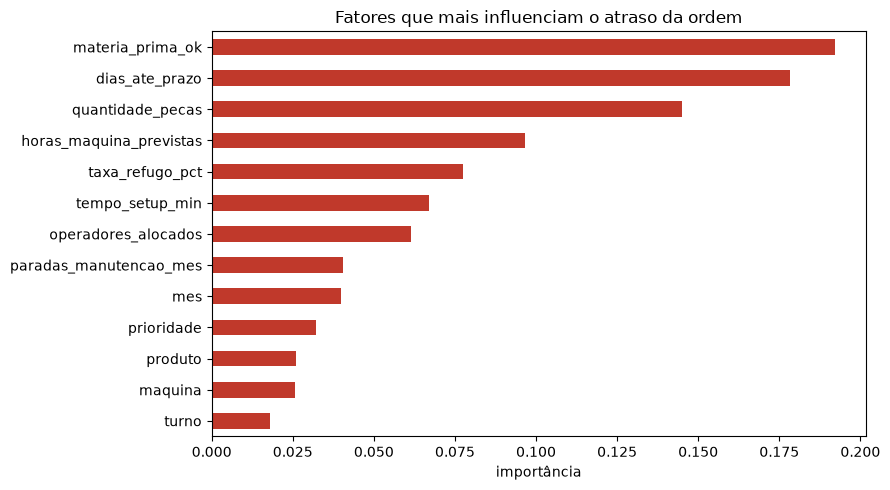

In [9]:
import matplotlib.pyplot as plt

importancias = pd.Series(modelo_arvore.feature_importances_, index=x.columns).sort_values()

plt.figure(figsize=(9, 5))
importancias.plot(kind="barh", color="#c0392b")
plt.title("Fatores que mais influenciam o atraso da ordem")
plt.xlabel("importância")
plt.tight_layout()
plt.savefig("assets/importancia_variaveis.png", dpi=120)
plt.show()

## 6. Prevendo as ordens novas

Ordens que acabaram de entrar no PCP (`novas_ordens.csv`). Aplico os mesmos codificadores salvos
antes e rodo o modelo vencedor.

In [10]:
novas = pd.read_csv("novas_ordens.csv")

for coluna, cod in codificadores.items():
    novas[coluna] = cod.transform(novas[coluna])

novas["status_prazo_previsto"] = modelo_arvore.predict(novas.drop(columns=["id_ordem"]))

novas[["id_ordem", "produto", "maquina", "prioridade",
       "quantidade_pecas", "dias_ate_prazo", "status_prazo_previsto"]]

,id_ordem,produto,maquina,prioridade,quantidade_pecas,dias_ate_prazo,status_prazo_previsto
0,OP-00001,0,3,0,3261,25,No_Prazo
1,OP-00002,0,0,0,3052,14,Atrasado
2,OP-00003,3,0,3,3840,3,Atrasado
3,OP-00004,1,3,2,2369,22,No_Prazo
4,OP-00005,1,4,0,2962,10,Atrasado
5,OP-00006,1,1,1,3450,43,Atrasado
6,OP-00007,2,0,3,3266,13,No_Prazo
7,OP-00008,1,0,0,3714,12,Atrasado
8,OP-00009,0,1,3,392,22,Adiantado
9,OP-00010,2,0,2,4653,17,Atrasado


## Conclusão

- O modelo consegue antecipar o risco de atraso com boa acurácia usando apenas dados que o PCP já acompanha no dia a dia.
- As variáveis de maior peso foram **prazo disponível, quantidade, matéria-prima e prioridade** — exatamente as alavancas que a produção usa para reagir.
- Próximo passo natural seria integrar isso à rotina: rodar o modelo toda manhã com as ordens da semana e montar um alerta de risco.

*Base de dados sintética, gerada pelo próprio `gerar_dados.py` para simular um histórico real de chão de fábrica.*